## importação

In [1]:
import random
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline


## Constantes e metas do SLA

In [2]:
RANDOM_SEED: int = 42
N_CHAMADOS:  int = 20
ID_INICIAL:  int = 1001

# Metas definidas no SLA da TechStore S.A.
META_SLA_ALTA:  float = 2.0   # horas
META_SLA_MEDIA: float = 8.0   # horas
META_SLA_BAIXA: float = 24.0  # horas

PRIORIDADES: list[str] = ["Alta", "Media", "Baixa"]

METAS_POR_PRIORIDADE: dict[str, float] = {
    "Alta":  META_SLA_ALTA,
    "Media": META_SLA_MEDIA,
    "Baixa": META_SLA_BAIXA,
}

CORES_PRIORIDADE: dict[str, str] = {
    "Alta":  "#e74c3c",
    "Media": "#f39c12",
    "Baixa": "#2ecc71",
}


## Geração do log de chamados

In [3]:
def gerar_log_chamados(n: int, seed: int = RANDOM_SEED) -> pd.DataFrame:
    """
    Gera um DataFrame com chamados fictícios de suporte técnico.

    @param n    Quantidade de chamados a gerar.
    @param seed Semente para reprodutibilidade.
    @return     DataFrame com colunas: ticket_id, prioridade,
                tempo_resolucao_horas.
    """
    random.seed(seed)

    dados = {
        "ticket_id": range(ID_INICIAL, ID_INICIAL + n),
        "prioridade": [random.choice(PRIORIDADES) for _ in range(n)],
        "tempo_resolucao_horas": [
            round(random.uniform(0.5, 5.0), 1) for _ in range(n)
        ],
    }

    return pd.DataFrame(dados)


df_log = gerar_log_chamados(N_CHAMADOS)
df_log


,ticket_id,prioridade,tempo_resolucao_horas
0,1001,Baixa,1.5
1,1002,Alta,3.2
2,1003,Alta,3.0
3,1004,Baixa,3.7
4,1005,Media,3.7
5,1006,Alta,2.4
6,1007,Alta,2.5
7,1008,Alta,1.8
8,1009,Baixa,4.4
9,1010,Alta,3.9


## Auditoria de Governança

In [4]:
def auditar_sla(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifica registros que violam a meta de SLA para cada prioridade.

    @param df DataFrame com colunas ticket_id, prioridade e
              tempo_resolucao_horas.
    @return   DataFrame contendo apenas os chamados em não-conformidade,
              acrescido das colunas 'meta_horas' e 'excesso_horas'.
    """
    df = df.copy()
    df["meta_horas"]   = df["prioridade"].map(METAS_POR_PRIORIDADE)
    df["excesso_horas"] = (df["tempo_resolucao_horas"] - df["meta_horas"]).round(1)

    return df[df["tempo_resolucao_horas"] > df["meta_horas"]].copy()


violacoes = auditar_sla(df_log)
violacoes


,ticket_id,prioridade,tempo_resolucao_horas,meta_horas,excesso_horas
1,1002,Alta,3.2,2.0,1.2
2,1003,Alta,3.0,2.0,1.0
5,1006,Alta,2.4,2.0,0.4
6,1007,Alta,2.5,2.0,0.5
9,1010,Alta,3.9,2.0,1.9
16,1017,Alta,2.2,2.0,0.2
17,1018,Alta,2.1,2.0,0.1


## Relatório de não-conformidades

In [5]:
total    = len(df_log)
n_viol   = len(violacoes)
taxa     = n_viol / total * 100

print("=" * 55)
print("  RELATÓRIO DE GOVERNANÇA — VIOLAÇÕES DE SLA")
print("=" * 55)
print("  Metas definidas no SLA:")
for prioridade, meta in METAS_POR_PRIORIDADE.items():
    print(f"    • {prioridade:<6} → até {meta:.0f}h")
print("=" * 55)

if violacoes.empty:
    print("  ✔  Nenhuma violação de conformidade detectada.")
else:
    print(violacoes[
        ["ticket_id", "prioridade", "tempo_resolucao_horas",
         "meta_horas", "excesso_horas"]
    ].to_string(index=False))
    print(f"\n  Total de não-conformidades: {n_viol}")
    print(f"  Taxa de violação geral:     {taxa:.1f}%")

print("=" * 55)


  RELATÓRIO DE GOVERNANÇA — VIOLAÇÕES DE SLA
  Metas definidas no SLA:
    • Alta   → até 2h
    • Media  → até 8h
    • Baixa  → até 24h
 ticket_id prioridade  tempo_resolucao_horas  meta_horas  excesso_horas
      1002       Alta                    3.2         2.0            1.2
      1003       Alta                    3.0         2.0            1.0
      1006       Alta                    2.4         2.0            0.4
      1007       Alta                    2.5         2.0            0.5
      1010       Alta                    3.9         2.0            1.9
      1017       Alta                    2.2         2.0            0.2
      1018       Alta                    2.1         2.0            0.1

  Total de não-conformidades: 7
  Taxa de violação geral:     35.0%


## Visualizações

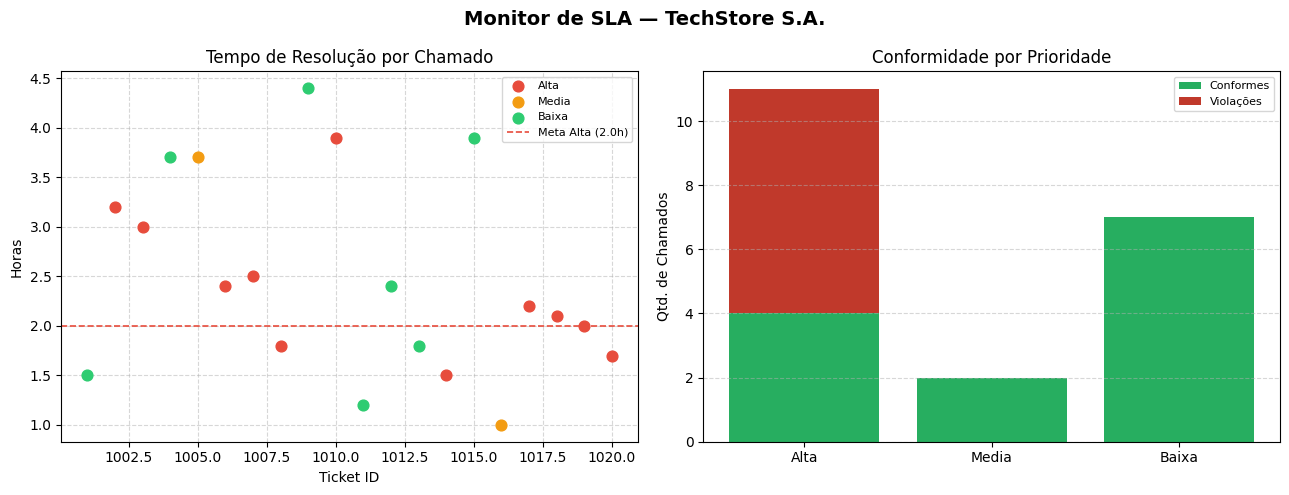

In [6]:
def gerar_graficos(df_log: pd.DataFrame, violacoes: pd.DataFrame) -> None:
    """
    Gera dois gráficos: dispersão dos tempos por chamado e
    comparativo de conformidade x violação por prioridade.

    @param df_log    DataFrame completo de chamados.
    @param violacoes DataFrame das não-conformidades.
    @return None
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Monitor de SLA — TechStore S.A.", fontsize=14, fontweight="bold")

    # Gráfico 1 — dispersão por chamado
    ax1 = axes[0]
    for prioridade in PRIORIDADES:
        subset = df_log[df_log["prioridade"] == prioridade]
        ax1.scatter(
            subset["ticket_id"],
            subset["tempo_resolucao_horas"],
            label=prioridade,
            color=CORES_PRIORIDADE[prioridade],
            zorder=3,
            s=60,
        )

    ax1.axhline(
        META_SLA_ALTA,
        color=CORES_PRIORIDADE["Alta"],
        linestyle="--",
        linewidth=1.2,
        label=f"Meta Alta ({META_SLA_ALTA}h)",
    )
    ax1.set_title("Tempo de Resolução por Chamado")
    ax1.set_xlabel("Ticket ID")
    ax1.set_ylabel("Horas")
    ax1.legend(fontsize=8)
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Gráfico 2 — conformidade por prioridade (barras empilhadas)
    ax2 = axes[1]
    resumo = {
        p: {
            "Conformes":  len(df_log[df_log["prioridade"] == p])
                          - len(violacoes[violacoes["prioridade"] == p]),
            "Violações":  len(violacoes[violacoes["prioridade"] == p]),
        }
        for p in PRIORIDADES
    }

    labels    = list(resumo.keys())
    conformes = [resumo[p]["Conformes"]  for p in labels]
    violados  = [resumo[p]["Violações"]  for p in labels]
    x = range(len(labels))

    ax2.bar(x, conformes, label="Conformes", color="#27ae60")
    ax2.bar(x, violados, bottom=conformes, label="Violações", color="#c0392b")
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(labels)
    ax2.set_title("Conformidade por Prioridade")
    ax2.set_ylabel("Qtd. de Chamados")
    ax2.legend(fontsize=8)
    ax2.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig("relatorio_sla.png", dpi=150)
    plt.show()


gerar_graficos(df_log, violacoes)
